<div align="center">
  <h1><b> Quantum Information </b></h1>
  <h2> Entanglement Monogamy </h2>
</div>

<br>
<b>Author:</b> <a target="_blank" href="https://github.com/camponogaraviera">Lucas Camponogara Viera</a>

# Table of Contents

- [Definition](#definition)
- [Contrast with the multipartite GHZ entangled state](#contrast-with-the-multipartite-ghz-entangled-state)
- [Contrast with the multipartite W entangled state](#contrast-with-the-multipartite-w-entangled-state)
- [Connection with the no-cloning theorem and QKD](#connection-with-the-no-cloning-theorem-and-qkd)

# &nbsp; <img valign="middle" height="45px" src="https://img.icons8.com/python" width="45" hspace="0px" vspace="0px"> Importing modules

In [1]:
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit import QuantumCircuit
from qiskit_aer import Aer, AerSimulator
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np

# Definition

Entanglement monogamy states that if two quantum systems, $A$ and $B$, are maximally entangled, then neither can share entanglement with a third system, $C$. 

Obs: Monogamy specifically refers to pairwise maximally entangled states.

**Proof:**



# Contrast with the multipartite GHZ entangled state

The Greenberger-Horne-Zeilinger (GHZ) state is a maximally entangled state of three qubits defined by:

$$|GHZ \rangle = \frac{1}{\sqrt2}(|000\rangle + |111\rangle).$$

**Does the multipartite entangled GHZ state violates monogamy?**

It does not violate monogamy because:
- The entanglement involves all three qubits simultaneously rather than pairwise entanglement between two qubits.
- If you trace out one qubit (e.g., qubit C), the remaining two qubits (A and B) are in a separable (non-entangled) state.

$$ Tr_c(\rho_{abc}) =  Tr_c(|\psi_{abc}\rangle \langle \psi_{abc}|) = ...$$

In [24]:
def GHZ():
    qc = QuantumCircuit(3,3) 
    qc.h([0]), qc.cx(0,1), qc.cx(1,2)
    print(Statevector.from_instruction(qc))
    return qc

qc = GHZ()
qc.draw() 

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐     
q_1: ─────┤ X ├──■──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘
c: 3/═══════════════

Measurement results: {'111 000': 503, '000 000': 521}


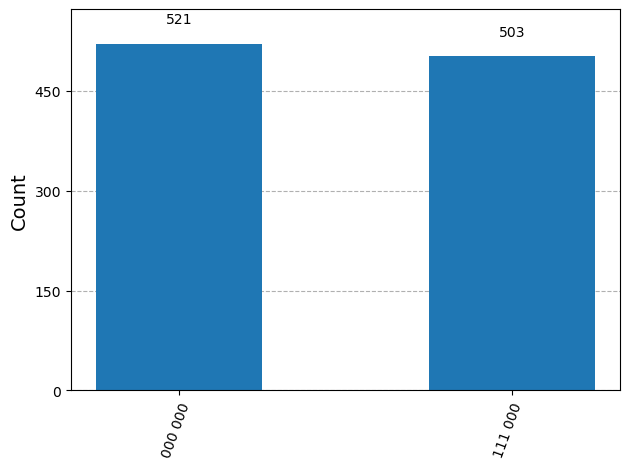

In [25]:
qc.measure_all()                                                  # Measuring all qubits. A quantum computer always measures in the computational basis.
backend = Aer.get_backend('qasm_simulator')                       # Define the Backend for the simulator.
job = backend.run(qc, shots=1024)
result = job.result()
counts = result.get_counts(qc)
print("Measurement results:", counts)                             # 
plot_histogram(counts)                                            # Plot a histogram of outcomes and corresponding probabilities.

# GHZ-like State

A GHZ-like state is the following:

$$|\psi \rangle = \frac{1}{\sqrt2}(|011\rangle - |100\rangle).$$

In [26]:
def GHZ_Like():
    qc = QuantumCircuit(3,3) 
    qc.h([0]), qc.x(2), qc.cx(0,1), qc.cx(1,2), qc.z(2)
    print(Statevector.from_instruction(qc))
    return qc

qc = GHZ_Like()
qc.draw() 

Statevector([ 0.        +0.j,  0.        +0.j,  0.        +0.j,
              0.70710678+0.j, -0.70710678+0.j,  0.        +0.j,
              0.        +0.j,  0.        +0.j],
            dims=(2, 2, 2))


┌───┐               
q_0: ┤ H ├──■────────────
     └───┘┌─┴─┐          
q_1: ─────┤ X ├──■───────
     ┌───┐└───┘┌─┴─┐┌───┐
q_2: ┤ X ├─────┤ X ├┤ Z ├
     └───┘     └───┘└───┘
c: 3/════════════════════

In [27]:
from qiskit.quantum_info import Statevector
import numpy as np

#from qiskit.opflow import One, Zero
#import math

# Define basis states
zero = Statevector.from_label('0')
one = Statevector.from_label('1')

# Build tensor products
state1 = Statevector.from_label('011')  # |011>
state2 = Statevector.from_label('100')  # |100>

# Create GHZ-like superposition
ghz_state = (1/np.sqrt(2)) * (state1.data - state2.data)

# Show as matrix (column vector)
print(ghz_state)

[ 0.        +0.j  0.        +0.j  0.        +0.j  0.70710678+0.j
 -0.70710678+0.j  0.        +0.j  0.        +0.j  0.        +0.j]


Measurement results: {'100 000': 531, '011 000': 493}


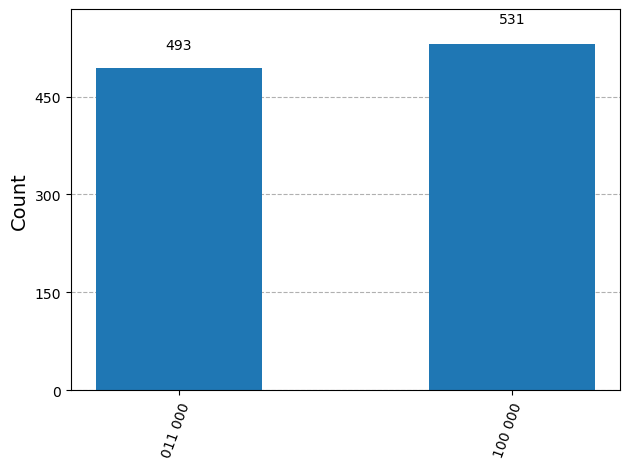

In [28]:
qc.measure_all()                                                  # Measuring all qubits. A quantum computer always measures in the computational basis.
backend = Aer.get_backend('qasm_simulator')                       # Define the Backend for the simulator.
job = backend.run(qc, shots=1024)
result = job.result()
counts = result.get_counts(qc)
print("Measurement results:", counts)                             # 
plot_histogram(counts)                                            # Plot a histogram of outcomes and corresponding probabilities.

# Contrast with the multipartite W entangled state

\begin{align}
|W\rangle_{3qb} &\doteq \frac{1}{\sqrt{3}} \left ( |001\rangle +  |010\rangle + |100\rangle \right).
\end{align} 

# Connection with the no-cloning theorem and QKD

The no-cloning theorem states that it is impossible to create an exact copy of an arbitrary unknown quantum state.

If cloning were allowed, a system _A_ could "clone" its quantum state and distribute entanglement freely to multiple systems, violating the principle of monogamy.

# &nbsp; <a href="#"><img valign="middle" height="45px" src="https://img.icons8.com/book" width="45" hspace="0px" vspace="0px"></a> References<a name="ref" />

\[1] Nielsen MA, Chuang IL. 2010. Quantum Computation and Quantum Information. New York: [Cambridge Univ. Press.](https://doi.org/10.1017/CBO9780511976667) 10th Anniv. Ed.